## Recursive SMARTS

In this notebook, we'll cover recursive SMARTS, a powerful technique for matching specific chemical features.  In contrast to a standard SMARTS pattern, where each atom in the pattern matches an atom in the target molecule, recursive SMARTS match a **single atom and its surrounding environment**.  As such, recursive SMARTS, are ideal when we want to assign labels to specific atoms.  As we will see below, the flexibility of recursive SMARTS also makes them helpful for several other purposes. 

In [1]:
%pip install rdkit


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from rdkit.Chem import rdDepictor
from rdkit import Chem

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = 300, 300
rdDepictor.SetPreferCoordGen(True)

To begin, let's define an example molecule with two different sidechains, a carboxylic acid and an aldehyde.

In [9]:
m1 = Chem.MolFromSmiles("OC(=O)c1cccc(C=O)c1")

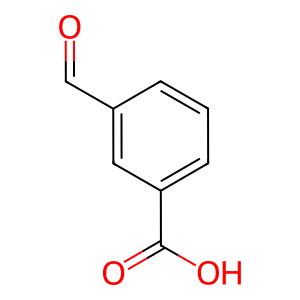

In [7]:
m1

If we define a SMARTS for a carbxoylic acid, the pattern matches 3 heavy (non-hydrogen) atoms. Remember that hydrogens in a SMARTS are simply specifiers for the attached heavy atom.

In [10]:
simple_acid_smarts = "C(=O)[OH]"
simple_acid_query = Chem.MolFromSmarts(simple_acid_smarts)

In [11]:
m1.GetSubstructMatches(simple_acid_query)

((1, 2, 0),)

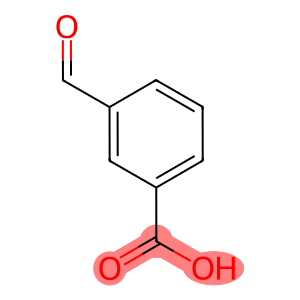

In [12]:
m1

In a recursive SMARTS, the smarts is enclosed by [$()]. This indicates that only the first atom in the SMARTS should be matched. Let's change the carboxylic acid SMARTS above to a recursive SMARTS.

In [13]:
recursive_acid_smarts = "[$(C(=O)[OH])]"
recursive_acid_query = Chem.MolFromSmarts(recursive_acid_smarts)

Note that the recursive SMARTS only matches one atom, the first atom in the pattern.

In [14]:
m1.GetSubstructMatches(recursive_acid_query)

((1,),)

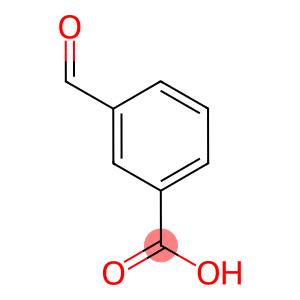

In [15]:
m1

Let's rewrite the SMARTS and make the carboxylate oxygen the first atom. Now notice that the matched atom changes.

In [16]:
rearranged_recursive_smarts = "[$([OH]C(=O))]"
rearranged_recursive_query = Chem.MolFromSmarts(rearranged_recursive_smarts)

In [17]:
m1.GetSubstructMatches(rearranged_recursive_query)

((0,),)

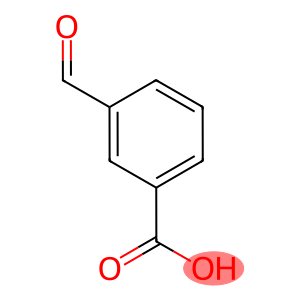

In [18]:
m1

Recursive SMARTS can also be combined to create more complex queries. Queries can be combined with "&" for AND or "," for OR. There is also the ";" operator, which represents AND with a lower priority than OR. In the example below, the carbonyl query below two atoms in the target molecule.

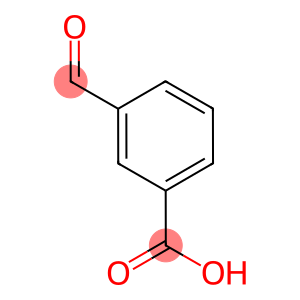

In [19]:
combo_query = Chem.MolFromSmarts("[$(C=O)]")
m1.GetSubstructMatches(combo_query)
m1

Recursive SMARTS can also represent a NOT condition by specifying a "!" operator. If we modify the recursive SMARTS above and change the second part to &!$([CD3]), the SMARTS matches carbonyl groups that do not have 3 connected heavy atoms.

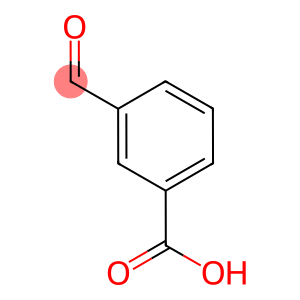

In [22]:
not_query = Chem.MolFromSmarts('[$(C=O)&!$([CD3])]')
m1.GetSubstructMatches(not_query)
m1

Recursive SMARTS also provide a convenient means of handling cases where multiple possibilities exist. As an example consider nitro groups. Show below are three different ways of representing a nitro group. Let's say we're designing a functional group filter and we want to be able to catch any of the three representations below. First let's create three versions of nitrobenzene with different nitro representations.

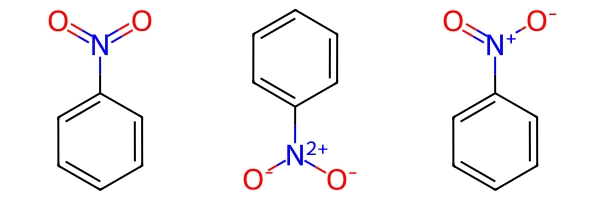

In [25]:
nitro_smi_list = ["c1ccccc1N(=O)(=O)","c1ccccc1[N+2]([O-])([O-])","c1ccccc1[N+](=O)([O-])"]
# In the following line, "sanitize = False" is used to prevent RDKit from altering the nitro groups while parsing the molecule. This allows the three different representations of the nitro group to be preserved and shown. However, the example also works without disabling sanitization.
nitro_mol_list = [Chem.MolFromSmiles(x, sanitize = False) for x in nitro_smi_list]
MolsToGridImage(nitro_mol_list)

We can then define a recursive SMARTS query which combines the three representation with a "," representing an "or" condition. The initial "N;" isn't strictly necessary, but I like writing the SMARTS this way to remind myself that I'm matching a single nitrogen.

In [29]:
nitro_query = Chem.MolFromSmarts("[N;$([N](=O)(=O)),$([N+2]([O-])([O-])),$([N+](=O)([O-]))]")

In [30]:
hal = [x.GetSubstructMatches(nitro_query)[0] for x in nitro_mol_list]

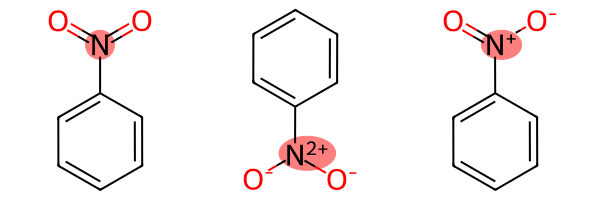

In [32]:
MolsToGridImage(nitro_mol_list, highlightAtomLists=hal)

---

## Summary SMARTS — recursive vs simple

**SMARTS** is a pattern language for finding substructures in molecules (like regex, but for chemical graphs). `GetSubstructMatches(query)` returns tuples of atom indices that match.

### Simple SMARTS
Matches **all atoms** written in the pattern.

```python
Chem.MolFromSmarts("C=O")
# matches → ((1, 2), (7, 8))  → each match is (carbon, oxygen)
```

### Recursive SMARTS — `[$(...)]`
Wrapping in `[$(...)]` turns a whole pattern into a **condition on a single atom**. It matches **only the first atom inside `$()`**; everything else is just context.

```python
Chem.MolFromSmarts("[$(C=O)]")
# matches → ((1,), (7,))  → only the carbon; =O is a condition
```

**The one rule to remember:** `[$(...)]` returns the *first atom* written inside `$()`. Reorder the atoms → different atom returned, same group.

```python
"[$(C(=O)[OH])]"   # returns the CARBOXYL CARBON
"[$([OH]C(=O))]"   # returns the HYDROXYL OXYGEN — same group, different anchor
```

### Combining conditions

| Operator | Meaning | Priority |
|---|---|---|
| `&` | AND | low |
| `,` | OR | medium |
| `;` | AND | lowest |
| `!` | NOT | — |

```python
# carbonyl carbon that is NOT a 3-connected carbon (excludes acids, keeps aldehydes)
"[$(C=O)&!$([CD3])]"

# nitro group in any of 3 representations (OR between branches)
"[N;$([N](=O)(=O)),$([N+2]([O-])([O-])),$([N+](=O)([O-]))]"
```

### Key atom primitives
- `D` = **degree** — number of heavy-atom neighbors (ignores implicit H). `D3` = 3 heavy neighbors.
- `X` = **connectivity** — total connections including H. `CX3` = carbon with 3 connections.
- `H` = attached hydrogens. `[OH]` = oxygen with one H.
- lowercase (`c`, `n`) = aromatic; uppercase (`C`, `N`) = aliphatic.

### Tips & gotchas

- **An outer atom symbol is often redundant.** In `[N;$([N]...),...]`, every `$()` branch already starts with `N`, so the leading `N;` does nothing — removing it changes nothing. It only matters when the branches *don't* start with the atom you want to anchor (e.g. `[N;$(O=[N])]` — here the branch starts with `O`, so `N;` is what makes the match land on nitrogen).

- **`[CD3]` vs `[D3]` aren't the same in general.** `[CD3]` requires carbon; `[D3]` matches any 3-connected atom. They coincide only when an outer condition (like `$(C=O)`) has already restricted the match to carbon.

- **`D` ignores hydrogens.** An aldehyde `-CHO` carbon has degree 2 (=O + ring C), *not* 3 — the H doesn't count. That's exactly why `!$([CD3])` keeps aldehydes but drops carboxylic acids.

- **Recursive SMARTS is for distinguishing look-alike atoms by environment** — alcohol O vs acid O, benzene C vs pyridine C, primary amine N vs amide N. Use it when you need the *index/coordinates of one specific atom* but its identity depends on its surroundings.

- **You rarely write these by hand for standardization** — `MolStandardize` tools (`Uncharger`, `TautomerEnumerator`, normalizers) use SMARTS rule sets internally, so your dedup pipeline already relies on them without you seeing it.